# European Options — Pricing and Greeks

## What is a European Option?

A **European option** is a financial contract that grants the holder the right, but not the obligation, to buy (call) or sell (put) an underlying asset at a fixed **strike price** $K$ on a single predetermined **expiry date** $T$. Unlike American options, early exercise is not permitted.

**Payoffs at expiry:**
- Call: $\max(S_T - K,\; 0)$
- Put:  $\max(K - S_T,\; 0)$

## Black-Scholes Pricing

Under the Black-Scholes model the underlying follows geometric Brownian motion:
$$dS = \mu S\,dt + \sigma S\,dW_t$$

The **closed-form prices** are:
$$C = S\,N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S\,N(-d_1)$$

where
$$d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $N(\cdot)$ is the standard normal CDF.

**Greeks** measure the sensitivity of the option price to model inputs:

| Greek | Symbol | Sensitivity to |
|-------|--------|----------------|
| Delta | $\Delta$ | Underlying spot price |
| Gamma | $\Gamma$ | Delta (second-order spot) |
| Vega  | $\mathcal{V}$ | Implied volatility |
| Theta | $\Theta$ | Time to maturity |
| Rho   | $\rho$ | Risk-free rate |

**Parameters used throughout this notebook:** $S=100$, $K=100$ (ATM), $\sigma=20\%$, $r=5\%$, $T \approx 1$ year.

In [1]:
from neon.lib.instruments.options.option_inputs import OptionInputs
from neon.lib.instruments.options.option_type import OptionType
from neon.lib.instruments.options.european import EuropeanOption
from neon.lib.greeks.analytical_greeks import AnalyticalGreeks
from neon.lib.greeks.numerical_greeks import NumericalGreeks
import matplotlib.pyplot as plt
import numpy as np

# Shared market parameters
TICKER = "SPX"
SPOT = 100.0
STRIKE = 100.0
VOL = 0.20
RATE = 0.05
CURRENT_DATE = "20250101"
EXPIRY_DATE = "20260101"

## 1. ATM Call and Put — Price and Greeks

We construct an at-the-money (ATM) call and put using `AnalyticalGreeks` (closed-form Black-Scholes) and print all six risk measures.

In [2]:
call_inputs = OptionInputs(
    underlying_ticker=TICKER,
    underlying_price=SPOT,
    strike_price=STRIKE,
    volatility=VOL,
    risk_free_rate=RATE,
    current_date=CURRENT_DATE,
    expiry_date=EXPIRY_DATE,
    option_type=OptionType.Call,
)

put_inputs = OptionInputs(
    underlying_ticker=TICKER,
    underlying_price=SPOT,
    strike_price=STRIKE,
    volatility=VOL,
    risk_free_rate=RATE,
    current_date=CURRENT_DATE,
    expiry_date=EXPIRY_DATE,
    option_type=OptionType.Put,
)

euro_call = EuropeanOption(call_inputs, AnalyticalGreeks())
euro_put  = EuropeanOption(put_inputs,  AnalyticalGreeks())

header = f"{'Greek':<8}  {'Call':>10}  {'Put':>10}"
print(header)
print("-" * len(header))
for greek in ["price", "delta", "gamma", "vega", "theta", "rho"]:
    c_val = getattr(euro_call, greek)()
    p_val = getattr(euro_put,  greek)()
    print(f"{greek:<8}  {c_val:>10.4f}  {p_val:>10.4f}")

# Put-call parity check: C - P = S - K * exp(-rT)
T = euro_call.time_to_maturity
pcp_lhs = euro_call.price() - euro_put.price()
pcp_rhs = SPOT - STRIKE * np.exp(-RATE * T)
print(f"\nPut-call parity: C - P = {pcp_lhs:.4f},  S - Ke^(-rT) = {pcp_rhs:.4f}")

Greek           Call         Put
--------------------------------
price        10.4506      5.5735
delta         0.6368     -0.3632
gamma         0.0188      0.0188
vega         37.5240     37.5240
theta        -6.4140     -1.6579
rho          53.2325    -41.8905

Put-call parity: C - P = 4.8771,  S - Ke^(-rT) = 4.8771


## 2. ITM and OTM Examples

We price calls and puts at three strikes:
- **ITM call / OTM put**: K = 90 (spot above strike)
- **ATM**: K = 100
- **OTM call / ITM put**: K = 110 (spot below strike)

Notice how moneyness affects both price levels and Greeks.

In [3]:
strikes = [90, 100, 110]
labels  = ["ITM call / OTM put", "ATM", "OTM call / ITM put"]

print("=== CALLS ===")
print(f"{'Strike':<8}  {'Moneyness':<20}  {'Price':>8}  {'Delta':>8}  {'Gamma':>8}  {'Vega':>8}")
print("-" * 70)
for k, label in zip(strikes, labels):
    inp = OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=SPOT,
        strike_price=float(k),
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=OptionType.Call,
    )
    opt = EuropeanOption(inp, AnalyticalGreeks())
    print(f"{k:<8}  {label:<20}  {opt.price():>8.4f}  {opt.delta():>8.4f}  {opt.gamma():>8.4f}  {opt.vega():>8.4f}")

print()
print("=== PUTS ===")
print(f"{'Strike':<8}  {'Moneyness':<20}  {'Price':>8}  {'Delta':>8}  {'Gamma':>8}  {'Vega':>8}")
print("-" * 70)
for k, label in zip(strikes, labels):
    inp = OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=SPOT,
        strike_price=float(k),
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=OptionType.Put,
    )
    opt = EuropeanOption(inp, AnalyticalGreeks())
    print(f"{k:<8}  {label:<20}  {opt.price():>8.4f}  {opt.delta():>8.4f}  {opt.gamma():>8.4f}  {opt.vega():>8.4f}")

=== CALLS ===
Strike    Moneyness                Price     Delta     Gamma      Vega
----------------------------------------------------------------------
90        ITM call / OTM put     16.6994    0.8097    0.0136   27.1626
100       ATM                    10.4506    0.6368    0.0188   37.5240
110       OTM call / ITM put      6.0401    0.4496    0.0198   39.5760

=== PUTS ===
Strike    Moneyness                Price     Delta     Gamma      Vega
----------------------------------------------------------------------
90        ITM call / OTM put      2.3101   -0.1903    0.0136   27.1626
100       ATM                     5.5735   -0.3632    0.0188   37.5240
110       OTM call / ITM put     10.6753   -0.5504    0.0198   39.5760


## 3. Analytical vs Numerical Greeks

`AnalyticalGreeks` uses closed-form Black-Scholes derivatives. `NumericalGreeks` computes all Greeks via **central finite differences** applied to any provided pricing function.

When we feed `NumericalGreeks` the same Black-Scholes price formula, the two methods should produce nearly identical results — any discrepancy is purely numerical truncation error from the finite-difference step size.

In [4]:
from scipy.stats import norm

def bs_price(
    underlying_price: float,
    strike_price: float,
    volatility: float,
    risk_free_rate: float,
    time_to_maturity: float,
    option_type: int,
) -> float:
    """Standalone Black-Scholes price — passed as pricing_fn to NumericalGreeks."""
    sigma_sqrt_t = volatility * time_to_maturity ** 0.5
    d1 = (np.log(underlying_price / strike_price) + (risk_free_rate + 0.5 * volatility ** 2) * time_to_maturity) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    phi = int(option_type)  # +1 for call, -1 for put
    return float(
        phi * (
            underlying_price * norm.cdf(phi * d1)
            - strike_price * np.exp(-risk_free_rate * time_to_maturity) * norm.cdf(phi * d2)
        )
    )

analytical = EuropeanOption(call_inputs, AnalyticalGreeks())
numerical  = EuropeanOption(call_inputs, NumericalGreeks(pricing_fn=bs_price))

print(f"{'Greek':<8}  {'Analytical':>12}  {'Numerical':>12}  {'|Diff|':>10}")
print("-" * 50)
for greek in ["price", "delta", "gamma", "vega", "theta", "rho"]:
    a_val = getattr(analytical, greek)()
    n_val = getattr(numerical,  greek)()
    print(f"{greek:<8}  {a_val:>12.6f}  {n_val:>12.6f}  {abs(a_val - n_val):>10.2e}")

Greek       Analytical     Numerical      |Diff|
--------------------------------------------------
price        10.450584     10.450584    0.00e+00
delta         0.636831      0.636745    8.60e-05
gamma         0.018762      0.018760    2.30e-06
vega         37.524035     37.520983    3.05e-03
theta        -6.414028     -6.414031    3.73e-06
rho          53.232482     53.232481    7.71e-07


## 4. Call and Put Price vs Spot

We sweep the spot price from 70 to 130 and plot call and put prices. Key observations:
- Call price rises as spot increases; put price falls.
- Both curves are convex (positive gamma).
- The **intrinsic value** (lower bound) kinks at the strike.

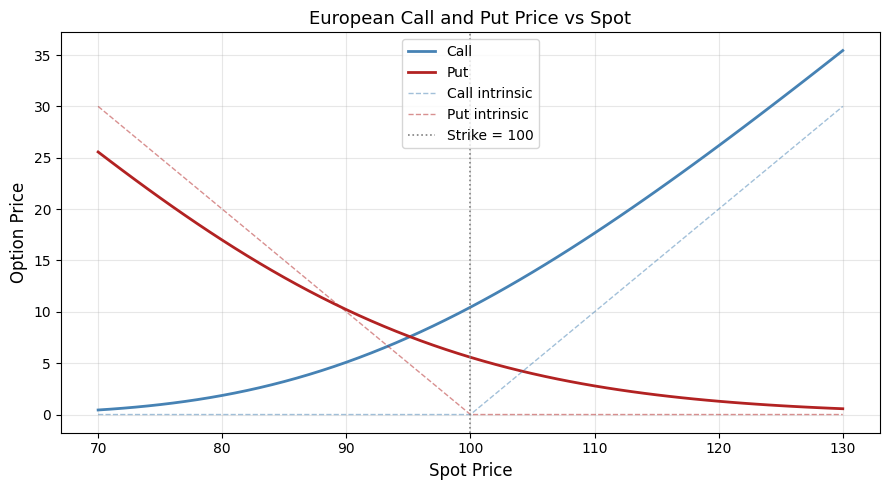

In [5]:
spots = np.arange(70, 131, 1, dtype=float)
call_prices = []
put_prices  = []

for s in spots:
    for prices_list, opt_type in [(call_prices, OptionType.Call), (put_prices, OptionType.Put)]:
        inp = OptionInputs(
            underlying_ticker=TICKER,
            underlying_price=float(s),
            strike_price=STRIKE,
            volatility=VOL,
            risk_free_rate=RATE,
            current_date=CURRENT_DATE,
            expiry_date=EXPIRY_DATE,
            option_type=opt_type,
        )
        prices_list.append(EuropeanOption(inp, AnalyticalGreeks()).price())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(spots, call_prices, color="steelblue",  linewidth=2, label="Call")
ax.plot(spots, put_prices,  color="firebrick",  linewidth=2, label="Put")
# Intrinsic value reference lines
ax.plot(spots, np.maximum(spots - STRIKE, 0), color="steelblue", linewidth=1,
        linestyle="--", alpha=0.5, label="Call intrinsic")
ax.plot(spots, np.maximum(STRIKE - spots, 0), color="firebrick", linewidth=1,
        linestyle="--", alpha=0.5, label="Put intrinsic")
ax.axvline(STRIKE, color="gray", linestyle=":", linewidth=1.2, label=f"Strike = {STRIKE:.0f}")
ax.set_xlabel("Spot Price", fontsize=12)
ax.set_ylabel("Option Price", fontsize=12)
ax.set_title("European Call and Put Price vs Spot", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Delta vs Spot

**Delta** measures the rate of change of option price with respect to spot. Key properties:
- Call delta ranges from 0 (deep OTM) to 1 (deep ITM).
- Put delta ranges from −1 (deep ITM) to 0 (deep OTM).
- At ATM the call delta is slightly above 0.5, reflecting the drift term.
- Call delta + |Put delta| ≈ 1 (put-call parity relationship).

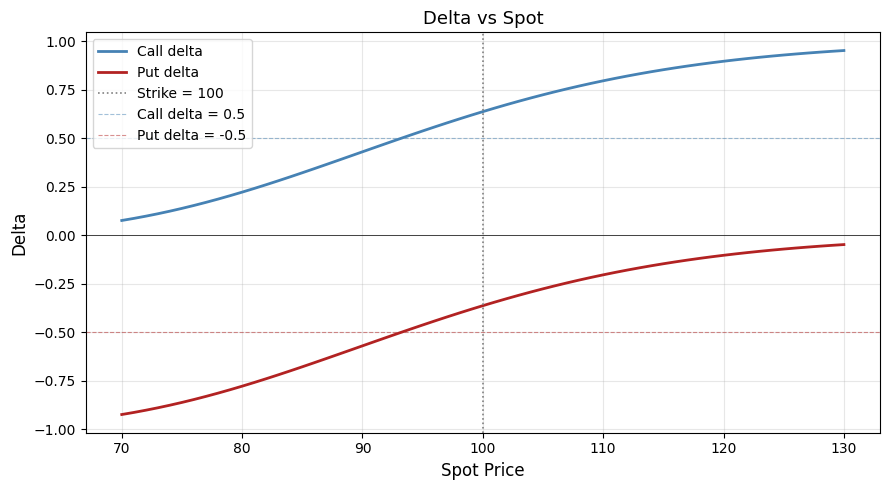

In [6]:
call_deltas = []
put_deltas  = []

for s in spots:
    for deltas_list, opt_type in [(call_deltas, OptionType.Call), (put_deltas, OptionType.Put)]:
        inp = OptionInputs(
            underlying_ticker=TICKER,
            underlying_price=float(s),
            strike_price=STRIKE,
            volatility=VOL,
            risk_free_rate=RATE,
            current_date=CURRENT_DATE,
            expiry_date=EXPIRY_DATE,
            option_type=opt_type,
        )
        deltas_list.append(EuropeanOption(inp, AnalyticalGreeks()).delta())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(spots, call_deltas, color="steelblue", linewidth=2, label="Call delta")
ax.plot(spots, put_deltas,  color="firebrick", linewidth=2, label="Put delta")
ax.axvline(STRIKE, color="gray",      linestyle=":",  linewidth=1.2, label=f"Strike = {STRIKE:.0f}")
ax.axhline(0.5,    color="steelblue", linestyle="--", linewidth=0.8, alpha=0.5, label="Call delta = 0.5")
ax.axhline(-0.5,   color="firebrick", linestyle="--", linewidth=0.8, alpha=0.5, label="Put delta = -0.5")
ax.axhline(0,      color="black",     linestyle="-",  linewidth=0.5)
ax.set_xlabel("Spot Price", fontsize=12)
ax.set_ylabel("Delta", fontsize=12)
ax.set_title("Delta vs Spot", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Gamma, Vega, and Theta vs Spot

- **Gamma**: rate of change of delta; peaks ATM and decays for both calls and puts (identical for calls and puts by Black-Scholes symmetry).
- **Vega**: sensitivity to volatility; also peaks ATM — ATM options are the most vol-sensitive.
- **Theta**: time decay (usually negative); most negative ATM where time value is greatest.

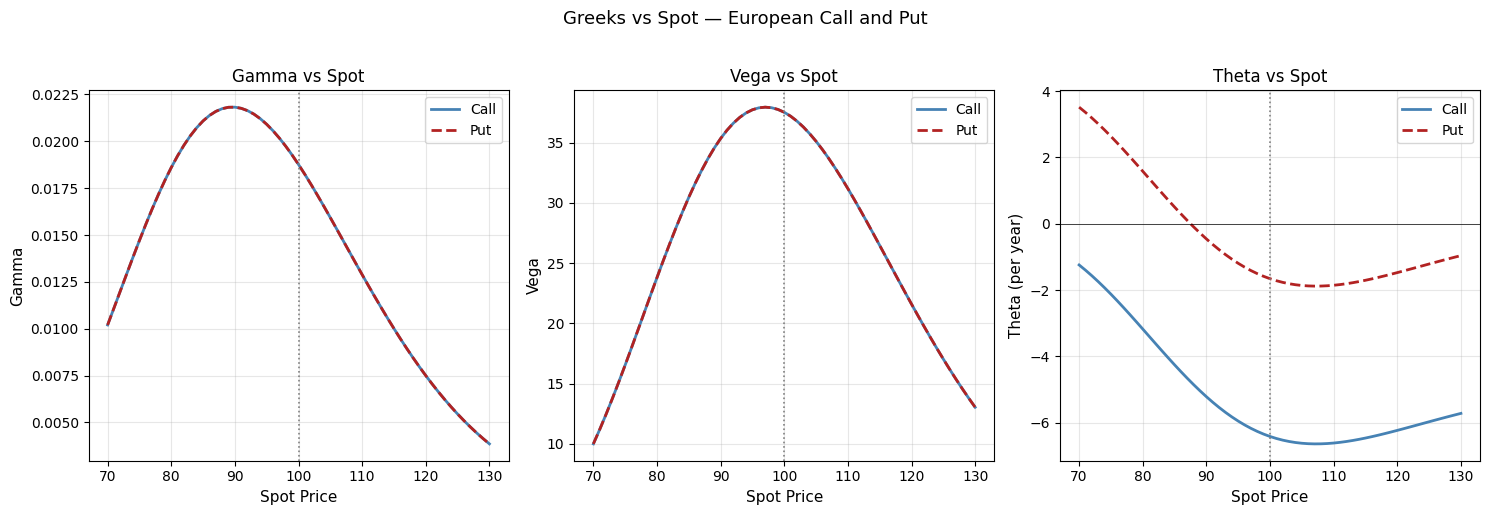

In [7]:
gammas_call  = []
vegas_call   = []
thetas_call  = []
gammas_put   = []
vegas_put    = []
thetas_put   = []

for s in spots:
    for g_list, v_list, t_list, opt_type in [
        (gammas_call, vegas_call, thetas_call, OptionType.Call),
        (gammas_put,  vegas_put,  thetas_put,  OptionType.Put),
    ]:
        inp = OptionInputs(
            underlying_ticker=TICKER,
            underlying_price=float(s),
            strike_price=STRIKE,
            volatility=VOL,
            risk_free_rate=RATE,
            current_date=CURRENT_DATE,
            expiry_date=EXPIRY_DATE,
            option_type=opt_type,
        )
        opt = EuropeanOption(inp, AnalyticalGreeks())
        g_list.append(opt.gamma())
        v_list.append(opt.vega())
        t_list.append(opt.theta())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gamma
axes[0].plot(spots, gammas_call, color="steelblue", linewidth=2, label="Call")
axes[0].plot(spots, gammas_put,  color="firebrick", linewidth=2, linestyle="--", label="Put")
axes[0].axvline(STRIKE, color="gray", linestyle=":", linewidth=1.2)
axes[0].set_xlabel("Spot Price", fontsize=11)
axes[0].set_ylabel("Gamma", fontsize=11)
axes[0].set_title("Gamma vs Spot", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Vega
axes[1].plot(spots, vegas_call, color="steelblue", linewidth=2, label="Call")
axes[1].plot(spots, vegas_put,  color="firebrick", linewidth=2, linestyle="--", label="Put")
axes[1].axvline(STRIKE, color="gray", linestyle=":", linewidth=1.2)
axes[1].set_xlabel("Spot Price", fontsize=11)
axes[1].set_ylabel("Vega", fontsize=11)
axes[1].set_title("Vega vs Spot", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Theta
axes[2].plot(spots, thetas_call, color="steelblue", linewidth=2, label="Call")
axes[2].plot(spots, thetas_put,  color="firebrick", linewidth=2, linestyle="--", label="Put")
axes[2].axvline(STRIKE, color="gray", linestyle=":", linewidth=1.2)
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_xlabel("Spot Price", fontsize=11)
axes[2].set_ylabel("Theta (per year)", fontsize=11)
axes[2].set_title("Theta vs Spot", fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Greeks vs Spot — European Call and Put", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()